[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/17_pytorch/52_pytorch_in_practice.ipynb)

# 📓 Notebook 52 — PyTorch in Practice: Embeddings, Baselines & Serving

> **Module:** Deep Learning with PyTorch (Module 17) · **Estimated time:** ~65 minutes · **Difficulty:** Advanced

NB 50 gave you the loop, NB 51 the craft. This closing lesson answers the business question: **when is any of it worth it on the tabular data you actually work with — and how does a trained network leave the notebook?** Three answers, in order:

1. **Embeddings** — deep learning's genuinely new gift to tabular data: categories become *learned vectors* instead of one-hot bit-strings. This idea, at scale, is also how LLMs see words — you'll recognise Module 6's "embeddings" (NB 23) as the same mechanism.
2. **An honest bake-off** — your embedding network vs. logistic regression vs. gradient boosting, same split, same metric, no thumb on the scale. The result calibrates a career's worth of tool choices.
3. **Shipping** — a sklearn-style wrapper so the net drops into any pipeline from Modules 4–5, and the export story (`state_dict` artifacts, TorchScript) that carries it toward the production world of Modules 11–12.

> 🧪 **Everything here runs 100% offline.** PyTorch is a local library — no key, no network; every model trains on CPU in seconds. Colab has torch preinstalled; without it, runtime cells check `HAS_TORCH` and skip gracefully.

> 🧭 **The mental model for the whole notebook.** *A category is a point in a learned space.* One-hot encoding (NB 16) plants every plan/region at the corner of its own axis — all equally far apart, no notion of similarity. An **embedding layer** instead gives each category coordinates and lets gradient descent *move them* until categories that behave alike sit close together. The model doesn't just use your categories; it learns their geography.

## ✅ Prerequisites

- **NB 50–51** — the training loop, `BCEWithLogitsLoss`, `DataLoader`, early stopping, `state_dict`. Assumed cold.
- **NB 16 (feature engineering)** — one-hot vs. ordinal vs. target encoding; embeddings join that menu.
- **NB 15 (model evaluation)** — ROC-AUC and honest comparison; the bake-off lives by its rules.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Explain what **`nn.Embedding`** is (a trainable lookup table), feed it **index tensors**, and pick a sensible embedding dimension.
2. Build a **tabular network** that combines embedded categoricals with scaled numeric features — the architecture behind entity-embedding models and Module 10's DeepTab.
3. Run an **honest bake-off** against logistic regression and gradient boosting — and articulate, from evidence, when deep learning earns its keep on tables.
4. Wrap a PyTorch model in a **sklearn-style estimator** (`fit` / `predict` / `predict_proba`) that handles vocabularies, scaling and early stopping internally — including **unseen categories**.
5. Package a trained model for **serving**: the three artifacts (weights, scaler, vocab), TorchScript export, and where ONNX/quantization fit (→ appendix A3).
6. Use the **decision guide**: for a given problem, choose between gradient boosting, an embedding net, transfer learning — or no deep learning at all.

## 1. The tabular reality check

Let's say the quiet part first, out loud: **on small-to-medium tables, gradient-boosted trees are the reigning champion.** A decade of Kaggle podiums and benchmark papers agree. If a colleague throws an MLP at 5,000 rows of churn data and reports beating tuned XGBoost, check their split before their genius.

So why does this lesson exist? Because the ledger has a second column — real situations where the network side wins:

| Deep learning earns its keep when… | Why trees struggle there |
|---|---|
| **High-cardinality categoricals** (10k customer IDs, SKUs, cities) | one-hot explodes; trees see arbitrary ID splits — embeddings learn *similarity* |
| **Mixed modalities** (table + ticket text + product image) | trees have no story for pixels/tokens; one network ingests all three |
| **Transfer learning** (pretrained on millions, fine-tuned on yours) | there is no "pretrained random forest" |
| **Representation reuse** (train once, feed embeddings to other models) | trees don't produce reusable vectors |
| **Huge data** (millions of rows, streaming updates) | batched SGD scales where tree libraries strain |

Today's plan: build the embedding network (§2–§4), make it race the champions honestly (§5), then ship it (§6–§7).

## 2. Setup — churn data with a second categorical

Same SaaS world, one enrichment (as NB 16 did): each customer now has a **`region`** — eight markets with genuinely different churn behaviour baked in. Two categoricals (`plan`, `region`) give the embedding layers something real to learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    HAS_TORCH = True
    torch.manual_seed(RANDOM_STATE)
    print(f"PyTorch {torch.__version__} — CPU is plenty for everything below.")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch not installed —", e)
    print("Install with:  pip install torch --index-url https://download.pytorch.org/whl/cpu")

/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTorch 2.12.0 — CPU is plenty for everything below.


In [2]:
# The NB 14/15 churn generator, enriched with a region column (as NB 16 enriched it)
rng = np.random.default_rng(RANDOM_STATE)
n = 600
REGIONS = ["DACH", "Nordics", "UK-I", "France", "Iberia", "Italy", "CEE", "Benelux"]
region_effect = {"DACH": 0.25, "Nordics": 0.30, "UK-I": 0.05, "France": 0.00,
                 "Iberia": -0.15, "Italy": -0.20, "CEE": -0.35, "Benelux": 0.10}

mrr_eur         = rng.lognormal(mean=6.5, sigma=0.7, size=n).clip(50, 50_000)
months_active   = rng.integers(1, 60, size=n)
support_tickets = rng.poisson(lam=2.5, size=n)
plan            = rng.choice(["Free", "Standard", "Premium", "Enterprise"],
                             size=n, p=[0.15, 0.45, 0.30, 0.10])
region          = rng.choice(REGIONS, size=n)
last_login_days = rng.integers(0, 90, size=n)

plan_adj = np.array([{"Free": -0.45, "Standard": 0.0, "Premium": 0.15, "Enterprise": 0.35}[p]
                     for p in plan])
region_adj = np.array([region_effect[r] for r in region])
happiness = (-0.40*(support_tickets-2.5)/2.0 - 0.80*(last_login_days-45)/30.0
             + 0.35*(np.log1p(mrr_eur)-6.5)/1.5 + 0.30*(months_active-30)/20.0
             + plan_adj + region_adj + rng.normal(0, 0.30, n))
nps = (40 + 35*happiness + rng.normal(0, 8, n)).clip(-100, 100)
churned = (rng.random(n) < 1/(1+np.exp(-(-1.6 - 2.5*happiness)))).astype(int)

churn_df = pd.DataFrame({"mrr_eur": mrr_eur, "months_active": months_active,
                         "support_tickets": support_tickets, "nps": nps,
                         "plan": plan, "region": region,
                         "last_login_days": last_login_days, "churned": churned})
NUM_COLS = ["mrr_eur", "months_active", "support_tickets", "nps", "last_login_days"]
CAT_COLS = ["plan", "region"]

print(churn_df.head(3).round(1).to_string())
print(f"\nchurn rate {churned.mean():.1%} · churn by region:")
print(churn_df.groupby("region")["churned"].mean().sort_values().round(2).to_string())

   mrr_eur  months_active  support_tickets   nps     plan   region  last_login_days  churned
0    823.3             15                1  32.1  Premium  Benelux               56        0
1    321.2             25                4  -3.3  Premium     UK-I               84        1
2   1124.7              5                3  28.0  Premium   Iberia               67        0

churn rate 27.8% · churn by region:
region
DACH       0.19
UK-I       0.20
Benelux    0.21
Nordics    0.26
CEE        0.33
Iberia     0.33
France     0.33
Italy      0.36


In [3]:
# Train / val / test split (60/20/20, as in NB 51), then scale numerics on train only
train_df, test_df = train_test_split(churn_df, test_size=0.20,
                                     random_state=RANDOM_STATE, stratify=churn_df["churned"])
train_df, val_df = train_test_split(train_df, test_size=0.25,
                                    random_state=RANDOM_STATE, stratify=train_df["churned"])
print(f"train {train_df.shape} · val {val_df.shape} · test {test_df.shape}")

scaler = StandardScaler().fit(train_df[NUM_COLS])

# Categorical VOCABULARIES, built on train — index 0 is reserved for "unknown/unseen"
vocabs = {c: {cat: i + 1 for i, cat in enumerate(sorted(train_df[c].unique()))} for c in CAT_COLS}
print("\nplan vocab  :", vocabs["plan"])
print("region vocab:", vocabs["region"])

def encode(df, fit_scaler=scaler):
    """DataFrame -> (cat index array int64, scaled numeric array float32, labels float32)."""
    cats = np.stack([df[c].map(lambda v: vocabs[c].get(v, 0)).to_numpy(np.int64)  # 0 = UNK
                     for c in CAT_COLS], axis=1)
    nums = fit_scaler.transform(df[NUM_COLS]).astype(np.float32)
    return cats, nums, df["churned"].to_numpy(np.float32)

cats_tr, nums_tr, y_tr = encode(train_df)
cats_va, nums_va, y_va = encode(val_df)
cats_te, nums_te, y_te = encode(test_df)
print("\ncats:", cats_tr.shape, cats_tr.dtype, "· nums:", nums_tr.shape, nums_tr.dtype)

train (360, 8) · val (120, 8) · test (120, 8)

plan vocab  : {'Enterprise': 1, 'Free': 2, 'Premium': 3, 'Standard': 4}
region vocab: {'Benelux': 1, 'CEE': 2, 'DACH': 3, 'France': 4, 'Iberia': 5, 'Italy': 6, 'Nordics': 7, 'UK-I': 8}

cats: (360, 2) int64 · nums: (360, 5) float32


> 💡 **Why index 0 = "unknown", already?** Vocabularies are frozen at training time, but the world isn't: next quarter Sales opens a **LATAM** region and your model meets a category it has never seen. Reserving slot 0 now means "anything unrecognised" has a home instead of a crash. The 🐞 debug-me shows exactly what happens without it.

## 3. `nn.Embedding` — a lookup table that learns

`nn.Embedding(num_categories, dim)` is nothing more than a **matrix with one row per category**. Feed it *integer indices* (that's why `cats` is `int64`) and it hands back the corresponding rows. The magic is only this: **those rows are parameters** — autograd flows into them, and `optimizer.step()` nudges each category's vector exactly like any weight.

Contrast with NB 16's one-hot: `region` one-hot is 8 frozen, mutually-orthogonal columns — *DACH is exactly as different from Nordics as from CEE*, forever. Embedded, each region starts as random coordinates and **drifts toward regions that behave similarly** as training sees churn happen.

Rule of thumb for the dimension (used by fastai and most practitioners): `dim ≈ min(50, (cardinality + 1) // 2)` — plans (4) get 2-3, regions (8) get 4, a 10,000-city column would get 50, not 10,000 one-hot columns.

In [4]:
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    emb_region = nn.Embedding(num_embeddings=len(vocabs["region"]) + 1, embedding_dim=4)  # +1 for UNK row 0

    idx = torch.tensor([vocabs["region"]["DACH"], vocabs["region"]["CEE"], 0])  # 0 = unknown
    vectors = emb_region(idx)
    print("indices", idx.tolist(), "-> vectors of shape", tuple(vectors.shape))
    print(vectors.detach().round(decimals=2))

    n_onehot = len(REGIONS)
    print(f"\none-hot width: {n_onehot} frozen columns · embedding: 4 learned dims"
          f"  (and it's trainable: requires_grad={emb_region.weight.requires_grad})")

indices [3, 2, 0] -> vectors of shape (3, 4)
tensor([[-0.7300, -0.5600, -0.7700,  0.7600],
        [-0.7500,  1.6500, -0.3900, -1.4000],
        [ 1.9300,  1.4900,  0.9000, -2.1100]])

one-hot width: 8 frozen columns · embedding: 4 learned dims  (and it's trainable: requires_grad=True)


Those vectors are random noise right now — untrained coordinates. Watch what training does to them: we'll fit a *minimal* model (region embedding → linear head, nothing else) so the only way it can reduce churn loss is by **arranging the region vectors usefully**.

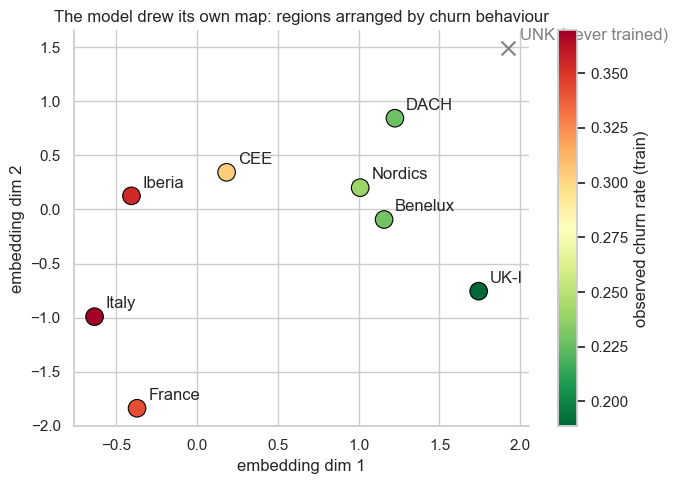

In [5]:
if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    tiny = nn.Sequential()  # placeholder for clarity; real model below
    emb = nn.Embedding(len(vocabs["region"]) + 1, 2)         # 2-D so we can PLOT the space
    head = nn.Linear(2, 1)
    opt = torch.optim.Adam(list(emb.parameters()) + list(head.parameters()), lr=0.05)
    loss_fn = nn.BCEWithLogitsLoss()

    region_idx = torch.from_numpy(cats_tr[:, CAT_COLS.index("region")])
    y_t = torch.from_numpy(y_tr)
    for _ in range(400):
        logits = head(emb(region_idx)).squeeze(1)
        loss = loss_fn(logits, y_t)
        loss.backward(); opt.step(); opt.zero_grad()

    coords = emb.weight.detach().numpy()
    fig, ax = plt.subplots(figsize=(7, 5))
    churn_by_region = train_df.groupby("region")["churned"].mean()
    sc = ax.scatter(coords[1:, 0], coords[1:, 1], s=160, c=[churn_by_region[r] for r in sorted(vocabs["region"])],
                    cmap="RdYlGn_r", edgecolor="black", lw=0.8)
    for r, i in vocabs["region"].items():
        ax.annotate(r, coords[i], textcoords="offset points", xytext=(8, 6))
    ax.scatter(*coords[0], marker="x", s=100, color="grey")
    ax.annotate("UNK (never trained)", coords[0], textcoords="offset points", xytext=(8, 6), color="grey")
    plt.colorbar(sc, label="observed churn rate (train)")
    ax.set(xlabel="embedding dim 1", ylabel="embedding dim 2",
           title="The model drew its own map: regions arranged by churn behaviour")
    sns.despine(); fig.tight_layout(); plt.show()

Nobody told the model that CEE and Italy are both high-churn markets — it *placed* them near each other because arranging the space that way lowered the loss. That is the entire pitch of representation learning, in one scatter plot. Scale the same mechanism up and: words with similar meanings cluster (NB 23's text embeddings), products bought together cluster (recommenders), customers who behave alike cluster. Same trick everywhere.

*(The grey ✗ is the UNK row — index 0 never appeared in training, so it stayed at its random birthplace. Unseen categories get a neutral, harmless vector — that's the crash-proofing from §2 paying off.)*

---

### ✋ Quick exercise (~2 min) — Who's closest to DACH?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Using the trained `emb` and `vocabs["region"]`, compute the **cosine similarity** between DACH's vector and every other region's (`torch.nn.functional.cosine_similarity` — or normalise and dot). Print the regions sorted by similarity. Do the neighbours make sense given the churn map above?

In [6]:
# ✍️ Your turn 👇
if HAS_TORCH:
    import torch.nn.functional as F
    dach = emb.weight[vocabs["region"]["DACH"]]
    # cosine similarity to each region's vector; sort and print
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    import torch.nn.functional as F
    dach = emb.weight[vocabs["region"]["DACH"]]
    sims = {r: F.cosine_similarity(dach, emb.weight[i], dim=0).item()
            for r, i in vocabs["region"].items() if r != "DACH"}
    for r, s in sorted(sims.items(), key=lambda kv: -kv[1]):
        print(f"{r:8}  {s:+.2f}")
```

Expect the *low-churn* markets (Nordics, Benelux…) at the top — training pushed retention-friendly regions into the same corner of the space. You've just done to regions what NB 23 did to sentences: **similarity = geometry**. (Directions in a 2-D space trained on one objective are crude; with more dims and more data, these similarities become genuinely useful features — stretch B exploits that.)
</details>

## 4. The tabular network — embeddings + numerics, joined

Now the real architecture — the one behind the "entity embeddings" papers and, industrial-strength, behind Module 10's DeepTab: **each categorical goes through its own embedding; the vectors are concatenated with the scaled numeric features; an MLP does the rest.**

```text
 plan ──▶ Embedding(5, 3)  ──┐
 region ─▶ Embedding(9, 4) ──┤ concat ▶ [3+4+5 = 12] ▶ Linear ▶ ReLU ▶ Dropout ▶ … ▶ logit
 5 numerics (scaled) ────────┘
```

In [7]:
if HAS_TORCH:
    class TabularNet(nn.Module):
        """Entity-embedding MLP: one embedding per categorical + scaled numerics -> logit."""
        def __init__(self, cardinalities, n_numeric, hidden=64, p_drop=0.2):
            super().__init__()
            self.embeddings = nn.ModuleList([
                nn.Embedding(card + 1, min(50, (card + 1) // 2))     # +1 -> row 0 is UNK
                for card in cardinalities
            ])
            emb_dim = sum(e.embedding_dim for e in self.embeddings)
            self.mlp = nn.Sequential(
                nn.Linear(emb_dim + n_numeric, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, 1),
            )

        def forward(self, x_cat, x_num):
            embedded = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            x = torch.cat(embedded + [x_num], dim=1)          # side-by-side, per row
            return self.mlp(x).squeeze(1)

    cards = [len(vocabs[c]) for c in CAT_COLS]                 # [4, 8]
    torch.manual_seed(RANDOM_STATE)
    net = TabularNet(cardinalities=cards, n_numeric=len(NUM_COLS))
    print(net)
    print(f"\nembedding dims: plan->{net.embeddings[0].embedding_dim}, region->{net.embeddings[1].embedding_dim}"
          f" · total parameters: {sum(p.numel() for p in net.parameters()):,}")

TabularNet(
  (embeddings): ModuleList(
    (0): Embedding(5, 2)
    (1): Embedding(9, 4)
  )
  (mlp): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

embedding dims: plan->2, region->4 · total parameters: 5,039


In [8]:
if HAS_TORCH:
    import copy

    def fit_tabular(model, cats, nums, y, cats_v, nums_v, y_v,
                    max_epochs=200, lr=1e-3, weight_decay=1e-3, patience=20, batch_size=64):
        """NB 51's recipe, adapted to (cat, num) pairs: batches, early stopping, best-restore."""
        ds = TensorDataset(torch.from_numpy(cats), torch.from_numpy(nums), torch.from_numpy(y))
        loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
        Xc_v, Xn_v, y_vt = torch.from_numpy(cats_v), torch.from_numpy(nums_v), torch.from_numpy(y_v)
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        loss_fn = nn.BCEWithLogitsLoss()
        best, since, best_state = float("inf"), 0, None
        for epoch in range(max_epochs):
            model.train()
            for xc, xn, yb in loader:
                loss = loss_fn(model(xc, xn), yb)
                loss.backward(); opt.step(); opt.zero_grad()
            model.eval()
            with torch.no_grad():
                val = loss_fn(model(Xc_v, Xn_v), y_vt).item()
            if val < best:
                best, since, best_state = val, 0, copy.deepcopy(model.state_dict())
            else:
                since += 1
                if since >= patience:
                    break
            last_epoch = epoch
        model.load_state_dict(best_state)
        return best

    best_val = fit_tabular(net, cats_tr, nums_tr, y_tr, cats_va, nums_va, y_va)
    net.eval()
    with torch.no_grad():
        proba_net = torch.sigmoid(net(torch.from_numpy(cats_te), torch.from_numpy(nums_te))).numpy()
    print(f"TabularNet: best val loss {best_val:.3f} · test ROC-AUC {roc_auc_score(y_te, proba_net):.3f}")

TabularNet: best val loss 0.323 · test ROC-AUC 0.859


---

### ✋ Quick exercise (~2 min) — Read the architecture like a bill

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Suppose next quarter the data team adds a `customer_city` column with **workable behaviour but 2,000 distinct values**. Using the rule of thumb and the `TabularNet` constructor: (a) what embedding dimension would it get (`min(50, (card+1)//2)`)? (b) how many parameters does *that one embedding table* add (`(2000+1) × dim`)? (c) for contrast, how many **columns** would one-hot add? Compute all three in code.

In [9]:
# ✍️ Your turn 👇
card = 2000
dim = ...
emb_params = ...
onehot_cols = ...
# print(dim, emb_params, onehot_cols)

<details>
<summary>✅ <b>Solution</b></summary>

```python
card = 2000
dim = min(50, (card + 1) // 2)            # -> 50
emb_params = (card + 1) * dim             # 2001 rows × 50 dims = 100,050 parameters
onehot_cols = card                        # 2,000 new columns in EVERY row
print(f"dim={dim} · embedding adds {emb_params:,} params · one-hot adds {onehot_cols:,} columns")
```

The embedding costs ~100k *parameters* (cheap — they live once, in the model), while one-hot costs 2,000 *columns in every single row of every dataset copy* — and a linear layer reading those columns would need its own 2,000+ weights anyway, with no similarity structure learned. High cardinality is exactly where embeddings switch from "nice" to "necessary" — stretch A stages the head-to-head.
</details>

## 5. The bake-off — no thumb on the scale

The moment of truth. Four contenders, identical train/test split, identical metric (test ROC-AUC), tuned the same reasonable-effort amount:

- **LogisticRegression** — the honest baseline every project must beat (one-hot features),
- **RandomForestClassifier** — bagged trees, the veteran,
- **HistGradientBoostingClassifier** — sklearn's LightGBM-style modern gradient booster, *native categorical support*,
- **TabularNet** — our embedding network (early-stopped on validation, as trained above).

For the sklearn models we merge train+val for fitting (they tune themselves via defaults; the network *used* the validation set for early stopping — giving both sides their customary diet).

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

trval_df = pd.concat([train_df, val_df])
y_trval = trval_df["churned"].values

onehot_prep = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
ordinal_prep = ColumnTransformer([
    ("num", "passthrough", NUM_COLS),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT_COLS),
])

contenders = {
    "LogisticRegression": Pipeline([("prep", onehot_prep),
                                    ("clf", LogisticRegression(max_iter=1000))]),
    "RandomForest": Pipeline([("prep", ordinal_prep),
                              ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))]),
    "HistGradientBoosting": Pipeline([("prep", ordinal_prep),
                                      ("clf", HistGradientBoostingClassifier(
                                          categorical_features=[len(NUM_COLS), len(NUM_COLS) + 1],
                                          random_state=RANDOM_STATE))]),
}

features = NUM_COLS + CAT_COLS
results = {}
for name, pipe in contenders.items():
    pipe.fit(trval_df[features], y_trval)
    results[name] = roc_auc_score(y_te, pipe.predict_proba(test_df[features])[:, 1])

if HAS_TORCH:
    results["TabularNet (PyTorch)"] = roc_auc_score(y_te, proba_net)

scoreboard = pd.Series(results).sort_values(ascending=False).round(3)
print("TEST ROC-AUC — one look, at the end, for everyone:\n")
print(scoreboard.to_string())

TEST ROC-AUC — one look, at the end, for everyone:

LogisticRegression      0.874
TabularNet (PyTorch)    0.859
RandomForest            0.821
HistGradientBoosting    0.791


### What the scoreboard teaches

Look who won: the **thirty-second, zero-tuning logistic regression** — with our embedding network a close second and *both* tree ensembles trailing. Three durable lessons, in ascending order of subtlety:

1. **The baseline is brutal — sometimes it's simply the answer.** This dataset was *generated* by a nearly linear process pushed through a logistic link (a latent "happiness" score — NB 14 told you so), so the simplest correctly-shaped model is close to unbeatable. Any complexity must earn its keep against *that*, not against zero.
2. **Rankings are dataset-specific; the *method* is what transfers.** On messier real-world tables — interactions, thresholds, weird marginals — gradient boosting very often sits on top, which is why it's the professional default first question. Here the trees spent their capacity hunting interactions that don't exist and paid for it in variance on 480 training rows. Never conclude "X beats Y" from one table — conclude it from *this procedure*: same split, same metric, one look at the end.
3. **The network paid rent differently.** Its near-baseline AUC bought embeddings (reusable geography — stretch B), a trunk that could *also* ingest text or images (stretch C goes multi-task), and mini-batch updateability. If you don't need any of those, you didn't need the network.

That's the professional posture: not "deep learning is overhyped", not "trees are old-fashioned" — *fit the tool to the problem*, with a scoreboard, not a vibe. (At 60,000 rows with a 5,000-value categorical, rerun this fight — the ranking genuinely flips around; NB 38 in Module 10 benchmarks modern deep-tabular models doing exactly that.)

## 6. A sklearn-style wrapper — the net joins your pipelines

Modules 4–5 gave you a workflow built around `fit` / `predict_proba` / `cross_val_score`. Your PyTorch model should *join* that world, not replace it. The wrapper below packages everything this module built — vocab building (with UNK), scaling, batching, early stopping, device safety — behind the two methods every sklearn tool expects. Subclassing `BaseEstimator` even makes it `clone`-able, so `cross_val_score` works (the bonus proves it).

In [11]:
if HAS_TORCH:
    from sklearn.base import BaseEstimator, ClassifierMixin

    class TorchTabularClassifier(ClassifierMixin, BaseEstimator):
        """DeepTab-lite: an entity-embedding MLP behind the sklearn API.

        (Mixin first, BaseEstimator second — that order is how modern sklearn
        learns this estimator is a *classifier*, so scorers ask for predict_proba.)
        """

        def __init__(self, cat_cols=None, num_cols=None, hidden=64, p_drop=0.2,
                     lr=1e-3, weight_decay=1e-3, max_epochs=200, patience=20,
                     batch_size=64, val_fraction=0.2, random_state=42):
            self.cat_cols, self.num_cols = cat_cols, num_cols
            self.hidden, self.p_drop = hidden, p_drop
            self.lr, self.weight_decay = lr, weight_decay
            self.max_epochs, self.patience = max_epochs, patience
            self.batch_size, self.val_fraction = batch_size, val_fraction
            self.random_state = random_state

        def _encode(self, X):
            cats = np.stack([X[c].map(lambda v: self.vocabs_[c].get(v, 0)).to_numpy(np.int64)
                             for c in self.cat_cols], axis=1)
            nums = self.scaler_.transform(X[self.num_cols]).astype(np.float32)
            return cats, nums

        def fit(self, X, y):
            y = np.asarray(y, dtype=np.float32)
            X_tr, X_va, y_tr, y_va = train_test_split(
                X, y, test_size=self.val_fraction, stratify=y, random_state=self.random_state)
            self.vocabs_ = {c: {cat: i + 1 for i, cat in enumerate(sorted(X_tr[c].unique()))}
                            for c in self.cat_cols}                     # 0 stays UNK
            self.scaler_ = StandardScaler().fit(X_tr[self.num_cols])
            torch.manual_seed(self.random_state)
            self.model_ = TabularNet([len(self.vocabs_[c]) for c in self.cat_cols],
                                     len(self.num_cols), hidden=self.hidden, p_drop=self.p_drop)
            fit_tabular(self.model_, *self._encode(X_tr), y_tr, *self._encode(X_va), y_va,
                        max_epochs=self.max_epochs, lr=self.lr, weight_decay=self.weight_decay,
                        patience=self.patience, batch_size=self.batch_size)
            self.classes_ = np.array([0, 1])
            return self

        def predict_proba(self, X):
            cats, nums = self._encode(X)
            self.model_.eval()
            with torch.no_grad():
                p1 = torch.sigmoid(self.model_(torch.from_numpy(cats), torch.from_numpy(nums))).numpy()
            return np.column_stack([1 - p1, p1])                        # sklearn's (n, 2) contract

        def predict(self, X):
            return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

    clf = TorchTabularClassifier(cat_cols=CAT_COLS, num_cols=NUM_COLS, random_state=RANDOM_STATE)
    clf.fit(trval_df[features], y_trval)
    print(f"wrapper test ROC-AUC: {roc_auc_score(y_te, clf.predict_proba(test_df[features])[:, 1]):.3f}")

wrapper test ROC-AUC: 0.851


One object now hides a vocabulary, a scaler, an embedding network, an early-stopped training run — and exposes the same three methods as `LogisticRegression`. Your colleagues don't need to know PyTorch to *use* it; NB 15's evaluation toolkit (calibration curves, threshold analysis, cost matrices) applies to it untouched. This is exactly the design of Module 10's **DeepTab** — research architectures (FT-Transformer, SAINT, Mamba) behind a scikit-learn API — built here in miniature so that library never feels like magic.

---

### ✋ Quick exercise (~2 min) — Drop it into NB 15's toolkit

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Prove the wrapper really speaks sklearn: run `sklearn.metrics.classification_report(y_te, clf.predict(test_df[features]))` and print it. Then get the churn probability for the **five riskiest** test customers (`predict_proba`, `np.argsort`) — the daily retention list, straight off a PyTorch model, in three lines of standard sklearn-style code.

In [12]:
# ✍️ Your turn 👇
if HAS_TORCH:
    from sklearn.metrics import classification_report
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    from sklearn.metrics import classification_report
    print(classification_report(y_te, clf.predict(test_df[features]), target_names=["stayed", "churned"]))

    proba = clf.predict_proba(test_df[features])[:, 1]
    riskiest = np.argsort(proba)[::-1][:5]
    print(test_df.iloc[riskiest][["plan", "region", "support_tickets", "last_login_days"]]
          .assign(churn_proba=proba[riskiest].round(2)).to_string())
```

No torch imports needed by the *caller* — that's the point of the wrapper. And notice who tops the risk list: high-ticket, long-idle, Free/CEE-ish customers, exactly the profile the data generator (and reality) makes fragile. A model you can slot into existing tooling is worth two that need their own ceremony.
</details>

## 7. Serving — what actually leaves the notebook

Module 11 taught the pattern: notebook → package → scheduled/served process. For a PyTorch tabular model, **three artifacts** must travel together, because inference must reproduce *the exact same preprocessing*:

```text
churn_model/
├── weights.pt        # model.state_dict()            (§7, NB 51)
├── scaler.pkl        # the FITTED StandardScaler     (joblib.dump)
└── vocabs.json       # category -> index, incl. UNK convention
```

Ship any two without the third and you get the classic production bug: a model that runs fine and predicts nonsense. The wrapper class *is* the natural unit — `joblib.dump(clf, ...)` captures all three at once for Python-to-Python serving.

For **crossing runtimes** (a C++ service, mobile, no-Python environments), PyTorch compiles the model itself:

In [13]:
if HAS_TORCH:
    # TorchScript: trace the model into a standalone, Python-free artifact
    example = (torch.from_numpy(cats_te[:2]), torch.from_numpy(nums_te[:2]))
    net.eval()
    scripted = torch.jit.trace(net, example)

    with torch.no_grad():
        same = torch.allclose(net(*example), scripted(*example))
    print("traced model gives identical outputs:", bool(same))

    from pathlib import Path
    p = Path("churn_tabnet.torchscript")
    scripted.save(str(p))
    print(f"saved {p} ({p.stat().st_size/1024:.0f} KB) — loadable via torch.jit.load, no class definition needed")
    p.unlink()  # tidy the demo file

traced model gives identical outputs: True
saved churn_tabnet.torchscript (43 KB) — loadable via torch.jit.load, no class definition needed


---

### ✋ Quick exercise (~2 min) — Round-trip the artifact

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Trust nothing you haven't reloaded. Save `scripted` (`scripted.save("roundtrip.torchscript")`), load it back with **`torch.jit.load`** into a *new* variable, verify with `torch.allclose` that it produces the same logits as `net` on the full test tensors (`cats_te`/`nums_te`), and delete the file (`Path("roundtrip.torchscript").unlink()`). That save → load → verify ritual is the minimum bar before any model artifact leaves your machine.

In [14]:
# ✍️ Your turn 👇
if HAS_TORCH:
    # 1) scripted.save(...)   2) reloaded_ts = torch.jit.load(...)
    # 3) torch.allclose against net on cats_te/nums_te   4) unlink the file
    reloaded_ts = ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    scripted.save("roundtrip.torchscript")
    reloaded_ts = torch.jit.load("roundtrip.torchscript")
    with torch.no_grad():
        a = net(torch.from_numpy(cats_te), torch.from_numpy(nums_te))
        b = reloaded_ts(torch.from_numpy(cats_te), torch.from_numpy(nums_te))
    print("reloaded TorchScript matches the live model:", bool(torch.allclose(a, b)))
    Path("roundtrip.torchscript").unlink()
```

Note what `torch.jit.load` did **not** need: the `TabularNet` class definition. The architecture travels *inside* the TorchScript file — that's its whole value over a bare `state_dict`, and why it can cross into runtimes that have never seen your Python code. (It still needs `scaler.pkl` and `vocabs.json` riding along — TorchScript packages the model, never the preprocessing.)
</details>

Reference notes for the rest of the export menu (all demonstrated hands-on in appendix [`A3_pytorch_fine_tuning.ipynb`](../04_machine_learning/A3_pytorch_fine_tuning.ipynb) §11–12):

```python
# ONNX — the cross-framework standard (runs in onnxruntime, C#, JS, mobile …)
# torch.onnx.export(net, example, "churn_tabnet.onnx",
#                   input_names=["cats", "nums"], output_names=["logit"])

# Dynamic quantization — int8 weights, ~4× smaller / faster on CPU, tiny accuracy cost
# q = torch.ao.quantization.quantize_dynamic(net, {nn.Linear}, dtype=torch.qint8)
```

And two pointers that close the loop with the rest of the course: wrap `clf.predict_proba` in a **FastAPI/Django endpoint** exactly as Modules 11/15 did for sklearn models (the wrapper's sklearn face means those chapters apply verbatim), and ship it through the **Module 12 CI/CD pipeline** like any other artifact. A PyTorch model in production is just a file plus a function — treat it with the same discipline as every other deployable.

## 8. The decision guide — choosing without ideology

The module's distilled judgment, one table:

| Your situation | Reach for |
|---|---|
| Tabular, < ~50k rows, modest cardinality | **Gradient boosting** (+ the logistic baseline). Revisit only with a reason. |
| Tabular + a few high-cardinality categoricals (IDs, SKUs, cities) | **Embedding net** (this lesson) or boosting with target encoding — race them. |
| Tabular at large scale, streaming updates, or embeddings wanted as features | **Embedding net / DeepTab** (Module 10; NB 38 benchmarks the modern architectures). |
| Tiny tabular dataset (≤ 10k rows) and you want strong accuracy *now* | **TabPFN** (appendix A4) — a pretrained tabular transformer, zero training. |
| Images, audio, sensor grids | **CNNs / pretrained vision models** — appendix A2, then transfer learning. |
| Text | **Pretrained transformers** — fine-tune (appendix A3) or prompt an LLM (Module 6); embeddings for search/RAG (NB 23). |
| Sequences / forecasting | Classical first (NB 11, DS appendices A1–A2), then **RNN/Transformer** (A2) or foundation forecasters (A4). |
| Any of the above, and honesty about uncertainty matters | add **conformal prediction** on top — appendix A5 wraps *any* of these models. |

Deep learning is a **capability**, not an obligation. You now hold both ends: the judgment to skip it, and the skill to wield it when the problem is worthy.

## 🧪 Practice exercises

These reuse the objects built above (`churn_df`, `vocabs`, `encode`, `TabularNet`, `fit_tabular`, `net`, `clf`). Try each before opening the solution.

### Exercise 1 — ⭐ An embedding is just indexed rows

Demystify the layer completely: create `e = nn.Embedding(6, 3)` (seeded), pick `idx = torch.tensor([4, 4, 1])`, and show that `e(idx)` equals `e.weight[idx]` — indexing the weight matrix directly (compare with `torch.equal`). Then explain in one sentence why the *same* index twice returns the *same* vector, and why that matters for a categorical feature.

In [15]:
# Your code here  👇
if HAS_TORCH:
    torch.manual_seed(0)
    e = nn.Embedding(6, 3)
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    torch.manual_seed(0)
    e = nn.Embedding(6, 3)
    idx = torch.tensor([4, 4, 1])
    print(e(idx))
    print("same as weight[idx]:", torch.equal(e(idx), e.weight[idx]))
```

`nn.Embedding` *is* `weight[idx]` — a differentiable row lookup, nothing more. The same index always returns the same row, which is exactly what a categorical needs: every "Premium" customer shares one vector, so every gradient from every Premium customer trains *the same three numbers*. (That sharing is also why rare categories still learn something.)
</details>

### Exercise 2 — ⭐⭐ Does the dimension matter?

The rule of thumb gave regions 4 dims. Test it: for `region_dim` in `[1, 4, 16]`, build a modified `TabularNet` where you *override* the region embedding (`net.embeddings[1] = nn.Embedding(9, region_dim)` after construction won't adjust the MLP — so instead, generalise: copy `TabularNet` into `TabularNetD` taking an explicit `dims` list). Train each with `fit_tabular` (fresh seed) and print validation-best loss and test AUC. Is more always better?

In [16]:
# Your code here  👇
if HAS_TORCH:
    class TabularNetD(nn.Module):
        def __init__(self, cardinalities, dims, n_numeric, hidden=64, p_drop=0.2):
            ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    class TabularNetD(nn.Module):
        def __init__(self, cardinalities, dims, n_numeric, hidden=64, p_drop=0.2):
            super().__init__()
            self.embeddings = nn.ModuleList([nn.Embedding(c + 1, d)
                                             for c, d in zip(cardinalities, dims)])
            emb_dim = sum(dims)
            self.mlp = nn.Sequential(
                nn.Linear(emb_dim + n_numeric, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, 1))
        def forward(self, x_cat, x_num):
            embedded = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            return self.mlp(torch.cat(embedded + [x_num], dim=1)).squeeze(1)

    for region_dim in [1, 4, 16]:
        torch.manual_seed(RANDOM_STATE)
        m = TabularNetD([4, 8], [2, region_dim], len(NUM_COLS))
        bv = fit_tabular(m, cats_tr, nums_tr, y_tr, cats_va, nums_va, y_va)
        m.eval()
        with torch.no_grad():
            auc = roc_auc_score(y_te, torch.sigmoid(
                m(torch.from_numpy(cats_te), torch.from_numpy(nums_te))).numpy())
        print(f"region_dim={region_dim:<3}  best val loss {bv:.3f}   test AUC {auc:.3f}")
```

With only 8 regions, `dim=1` compresses them onto a line (it can still rank them by churn-iness — often surprisingly adequate!), `dim=4` has room for structure, and `dim=16` mostly adds parameters for the regulariser to fight. The rule of thumb isn't sacred; it's a *starting bid* for a dial you read, as always, off validation.
</details>

### Exercise 3 — ⭐⭐ The wrapper meets the evaluation toolkit

`TorchTabularClassifier` claims full NB 15 compatibility — collect on that claim. Using `clf` (already fitted) and the test set: (a) plot the **calibration curve** (`sklearn.calibration.CalibrationDisplay.from_predictions`, 10 bins); (b) compute the **cost-weighted best threshold** where a missed churner costs €500 and a needless retention call €50 — sweep thresholds `0.05..0.95`, print the cost-minimising one. *(Both are NB 15 moves, applied unchanged to a deep model — that's the punchline.)*

In [17]:
# Your code here  👇
if HAS_TORCH:
    from sklearn.calibration import CalibrationDisplay
    proba = clf.predict_proba(test_df[features])[:, 1]
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    from sklearn.calibration import CalibrationDisplay
    proba = clf.predict_proba(test_df[features])[:, 1]

    CalibrationDisplay.from_predictions(y_te, proba, n_bins=10)
    plt.title("Is the wrapper's 70% really 70%?")
    plt.tight_layout(); plt.show()

    costs = {}
    for t in np.arange(0.05, 0.96, 0.05):
        pred = proba > t
        fn = ((y_te == 1) & ~pred).sum()          # missed churners
        fp = ((y_te == 0) & pred).sum()           # needless calls
        costs[round(t, 2)] = 500 * fn + 50 * fp
    best_t = min(costs, key=costs.get)
    print(f"cost-optimal threshold: {best_t}  (total cost €{costs[best_t]:,} "
          f"vs €{costs[0.5]:,} at the default 0.5)")
```

With misses 10× dearer than calls, the optimal threshold slides well **below** 0.5 — call more people, miss fewer churners. Neural nets can run over-confident (mild S-bend in the calibration curve); if it matters, `CalibratedClassifierCV` wraps our wrapper like any estimator. Every tool from NB 15 just worked on a PyTorch model — because we made the model speak sklearn.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

Marketing launches in **LATAM** 🎉. The first customer arrives, and a colleague's scoring code — which builds its vocabulary *without* an UNK slot and maps categories with `vocab[r]` — is below. Run it, enjoy the crash, then fix scoring so any unseen category lands safely (you know the convention). Bonus thought: why is a crash here *better* than the subtler failure of `vocab.get(r, len(vocab))`?

In [18]:
# 👇 Buggy on purpose — run it, read the traceback, then write your fix below.
if HAS_TORCH:
    naive_vocab = {r: i for i, r in enumerate(sorted(train_df["region"].unique()))}   # no UNK slot!
    new_customer = pd.DataFrame([{"mrr_eur": 900.0, "months_active": 12, "support_tickets": 1,
                                  "nps": 30.0, "plan": "Premium", "region": "LATAM",
                                  "last_login_days": 5}])
    idx = torch.tensor([naive_vocab[r] for r in new_customer["region"]])   # 💥
    print("never reached:", idx)
else:
    print("PyTorch not available — skipping.")

KeyError: 'LATAM'

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    # Fix: the module's convention — index 0 is reserved for unknown/unseen,
    # real categories start at 1, and lookups use .get(r, 0).
    safe_vocab = {r: i + 1 for i, r in enumerate(sorted(train_df["region"].unique()))}
    idx = torch.tensor([safe_vocab.get(r, 0) for r in new_customer["region"]])
    print("LATAM ->", idx.tolist(), "(the UNK row — neutral vector, no crash)")

    # The full pipeline handles it end-to-end, because encode()/the wrapper use .get(r, 0):
    print("wrapper says:", clf.predict_proba(new_customer[features])[0, 1].round(3))
```

`naive_vocab[r]` raises `KeyError` — loud, immediate, fixable. The tempting `vocab.get(r, len(vocab))` is far worse: for an 8-region vocab and `nn.Embedding(8, d)` it produces index 8 on a table whose rows are 0–7 → an `IndexError` *only when a LATAM row happens through*, or — if the table happens to be bigger — silently reads some *other category's learned vector.* Sizing tables `cardinality + 1` and reserving **0 = UNK at training time** (so the row exists *and* is harmless) is the boring convention that prevents both. Boring conventions are how models survive contact with Sales.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ High cardinality: where one-hot dies

Manufacture the regime the reality-check table promised. Give each customer a `city` drawn from 60 synthetic cities, where each city has a hidden churn-effect (`rng.normal(0, 0.4, 60)`) added into a *new* churn label. Then compare, on a fresh split: (a) logistic regression on one-hot cities (60 extra columns), (b) `TorchTabularClassifier` with `cat_cols=["plan", "region", "city"]`. Report test AUCs and the one-hot matrix's width. *(With 600 rows and 60 cities — 10 rows per city — expect a photo finish or better for embeddings, and note how the one-hot width scales vs. the embedding's ~`(61)×30` parameters if cities grew 100×.)*

In [19]:
# Your code here  👇
if HAS_TORCH:
    rng2 = np.random.default_rng(7)
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    rng2 = np.random.default_rng(7)
    cities = [f"city_{i:02d}" for i in range(60)]
    city_effect = dict(zip(cities, rng2.normal(0, 0.4, 60)))
    df2 = churn_df.copy()
    df2["city"] = rng2.choice(cities, len(df2))
    h2 = happiness + df2["city"].map(city_effect).to_numpy()
    df2["churned"] = (rng2.random(len(df2)) < 1/(1+np.exp(-(-1.6 - 2.5*h2)))).astype(int)

    tr2, te2 = train_test_split(df2, test_size=0.25, random_state=7, stratify=df2["churned"])
    feats2 = NUM_COLS + ["plan", "region", "city"]

    onehot = ColumnTransformer([("num", StandardScaler(), NUM_COLS),
                                ("cat", OneHotEncoder(handle_unknown="ignore"),
                                 ["plan", "region", "city"])])
    logreg = Pipeline([("prep", onehot), ("clf", LogisticRegression(max_iter=2000))])
    logreg.fit(tr2[feats2], tr2["churned"])
    width = logreg.named_steps["prep"].transform(tr2[feats2]).shape[1]
    auc_lr = roc_auc_score(te2["churned"], logreg.predict_proba(te2[feats2])[:, 1])

    deep = TorchTabularClassifier(cat_cols=["plan", "region", "city"], num_cols=NUM_COLS,
                                  random_state=7)
    deep.fit(tr2[feats2], tr2["churned"].values)
    auc_nn = roc_auc_score(te2["churned"], deep.predict_proba(te2[feats2])[:, 1])

    print(f"one-hot logistic : AUC {auc_lr:.3f}  (feature matrix width {width})")
    print(f"embedding net    : AUC {auc_nn:.3f}  (city table: 61 rows × {min(50, 61//2)} dims)")
```

At 60 cities the two usually finish close — one-hot logistic is tougher than folklore admits — but look at the *derivatives*: one-hot width grows linearly with cardinality (6,000 cities → 6,000 columns, ~10 one-hot rows per coefficient to estimate), while the embedding grows only its lookup table and can *share* statistical strength between similar cities. High cardinality plus real volume is where the embedding column of the §1 ledger stops being theoretical. (The third contender worth racing here: boosting + target encoding, NB 16.)
</details>

### Stretch exercise B — ⭐⭐⭐ Embeddings as features — for *other* models

The subtlest payoff of §3: a trained embedding is a **feature factory**. Extract the trained `net`'s region vectors (`net.embeddings[1].weight`), attach each customer's 4-D region vector to the *numeric* features, and train a plain `LogisticRegression` on `numerics + region-embedding` (no one-hot!). Compare test AUC against logistic-with-one-hot from §5. You've reproduced, in miniature, a workhorse industry pattern: deep model learns representations → simple, auditable model consumes them.

In [20]:
# Your code here  👇
if HAS_TORCH:
    region_vectors = net.embeddings[1].weight.detach().numpy()
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    region_vectors = net.embeddings[1].weight.detach().numpy()   # (9, 4): row 0 = UNK

    def with_region_emb(df):
        idx = df["region"].map(lambda r: vocabs["region"].get(r, 0)).to_numpy()
        emb_feats = region_vectors[idx]                          # (n, 4)
        nums = scaler.transform(df[NUM_COLS])
        return np.hstack([nums, emb_feats])

    lr_emb = LogisticRegression(max_iter=1000).fit(with_region_emb(trval_df), y_trval)
    auc_emb = roc_auc_score(y_te, lr_emb.predict_proba(with_region_emb(test_df))[:, 1])
    print(f"logistic + region EMBEDDING features: AUC {auc_emb:.3f}")
    print(f"logistic + one-hot (from §5)        : AUC {results['LogisticRegression']:.3f}")
```

Four learned columns replace eight one-hot columns at (typically) par accuracy — and the win compounds with cardinality: 6,000 cities become 50 columns any model can eat, including models that must stay simple for governance reasons (Module 14's explainability requirements). Word2vec-style text pipelines, retail SKU models and the two-tower recommenders behind "customers also bought" all run on this exact pattern.
</details>

### Stretch exercise C — ⭐⭐⭐ Two heads, one trunk — multi-task learning

The business wants churn risk *and* an NPS estimate. One network can serve both — and often each task improves the other, because the shared trunk must learn features useful for *both* (a soft regulariser). Build `TwoHeadNet`: the same embeddings+trunk as `TabularNet`, but two output heads — `churn_logit` and `nps_pred`. Train with a combined loss `BCEWithLogitsLoss(churn) + 0.01 * MSELoss(nps)` (the 0.01 balances the scales — NPS errors are ~100× bigger numbers). Report test churn-AUC and NPS MAE, and compare the AUC to the single-task `net`.

In [21]:
# Your code here  👇
if HAS_TORCH:
    class TwoHeadNet(nn.Module):
        ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    class TwoHeadNet(nn.Module):
        def __init__(self, cardinalities, n_numeric, hidden=64, p_drop=0.2):
            super().__init__()
            self.embeddings = nn.ModuleList([nn.Embedding(c + 1, min(50, (c + 1) // 2))
                                             for c in cardinalities])
            emb_dim = sum(e.embedding_dim for e in self.embeddings)
            self.trunk = nn.Sequential(nn.Linear(emb_dim + n_numeric, hidden), nn.ReLU(),
                                       nn.Dropout(p_drop), nn.Linear(hidden, hidden), nn.ReLU())
            self.churn_head = nn.Linear(hidden, 1)
            self.nps_head = nn.Linear(hidden, 1)
        def forward(self, x_cat, x_num):
            z = torch.cat([emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)] + [x_num], dim=1)
            h = self.trunk(z)
            return self.churn_head(h).squeeze(1), self.nps_head(h).squeeze(1)

    nps_tr = torch.from_numpy(train_df["nps"].to_numpy(np.float32))
    torch.manual_seed(RANDOM_STATE)
    two = TwoHeadNet([4, 8], len(NUM_COLS))
    opt = torch.optim.Adam(two.parameters(), lr=1e-3, weight_decay=1e-3)
    bce, mse = nn.BCEWithLogitsLoss(), nn.MSELoss()
    Xc, Xn, yt = torch.from_numpy(cats_tr), torch.from_numpy(nums_tr), torch.from_numpy(y_tr)
    for _ in range(150):
        two.train()
        churn_logit, nps_hat = two(Xc, Xn)
        loss = bce(churn_logit, yt) + 0.01 * mse(nps_hat, nps_tr)
        loss.backward(); opt.step(); opt.zero_grad()

    two.eval()
    with torch.no_grad():
        cl, nh = two(torch.from_numpy(cats_te), torch.from_numpy(nums_te))
    print(f"multi-task churn AUC: {roc_auc_score(y_te, torch.sigmoid(cl).numpy()):.3f}"
          f"   (single-task net: {roc_auc_score(y_te, proba_net):.3f})")
    print(f"multi-task NPS MAE : {np.abs(nh.numpy() - test_df['nps'].to_numpy()).mean():.1f} points")
```

One forward pass, two business answers — and this dataset is multi-task friendly *by construction* (a shared latent "happiness" drives both labels, as NB 14 disclosed), which is exactly the situation where sharing a trunk helps. The λ=0.01 balancing act is real: multi-task losses live on different scales, and un-balanced they let one task bully the other. Trees, note, have no equivalent of this move.
</details>

### Stretch exercise D — ⭐⭐⭐ Text joins the table — `nn.EmbeddingBag`

Bridge to the NLP world: each churned-or-not customer also wrote a short support note. Below is a tiny labelled set of such notes (positive/negative tone). Build the ultra-classic baseline text model: tokenise by `.lower().split()`, build a word vocab (0 = UNK), and use **`nn.EmbeddingBag`** (embeds every word and *averages* them — a whole sentence becomes one vector) followed by `Linear(16, 1)`. Train on 12 notes, test on the 4 held-out ones. This "average of word embeddings" is the primitive ancestor of NB 23's sentence-transformers — and appendix A3 replaces it with a real pretrained transformer.

In [22]:
# Your code here  👇
if HAS_TORCH:
    notes = [("great support fast reply thanks", 1), ("love the new dashboard", 1),
             ("billing issue resolved quickly", 1), ("very helpful onboarding call", 1),
             ("excellent product works perfectly", 1), ("quick fix much appreciated", 1),
             ("renewal was easy and smooth", 1), ("support team is fantastic", 1),
             ("cannot login again this week", 0), ("invoice wrong for third time", 0),
             ("slow replies and no solution", 0), ("app crashes every day", 0),
             ("still waiting since last month", 0), ("worst support experience ever", 0),
             ("price increase without notice", 0), ("feature broken after update", 0)]
    train_notes, test_notes = notes[:6] + notes[8:14], notes[6:8] + notes[14:]
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution</b></summary>

```python
if HAS_TORCH:
    vocab_txt = {}
    for text, _ in train_notes:
        for w in text.lower().split():
            vocab_txt.setdefault(w, len(vocab_txt) + 1)        # 0 stays UNK

    def to_indices(text):
        return torch.tensor([vocab_txt.get(w, 0) for w in text.lower().split()])

    torch.manual_seed(RANDOM_STATE)
    bag = nn.EmbeddingBag(len(vocab_txt) + 1, 16)              # embeds + MEANS the words
    head = nn.Linear(16, 1)
    opt = torch.optim.Adam(list(bag.parameters()) + list(head.parameters()), lr=0.05)
    loss_fn = nn.BCEWithLogitsLoss()

    X_idx = torch.cat([to_indices(t) for t, _ in train_notes])
    offsets = torch.tensor([0] + [len(to_indices(t)) for t, _ in train_notes]).cumsum(0)[:-1]
    y_txt = torch.tensor([float(l) for _, l in train_notes])

    for _ in range(200):
        loss = loss_fn(head(bag(X_idx, offsets)).squeeze(1), y_txt)
        loss.backward(); opt.step(); opt.zero_grad()

    bag.eval(); head.eval()
    with torch.no_grad():
        for text, label in test_notes:
            p = torch.sigmoid(head(bag(to_indices(text).unsqueeze(0)))).item()
            print(f"p(positive)={p:.2f}  true={label}  · {text!r}")
```

Words → indices → vectors → *mean* → classifier: sentence understanding as pure geometry, trained by the same five-step loop (the `offsets` tensor is just `EmbeddingBag`'s way of packing variable-length sentences into one flat batch). It scores the held-out notes right mostly on word overlap — no word order, no context ("not great" ≈ "great"!) — which is precisely the gap attention and transformers (appendix A2 §3, A3) exist to close. The bridge from this cell to an LLM is long, but it is *continuous*.
</details>

## 🎁 Bonus mini-project — DeepTab-lite, certified

Give `TorchTabularClassifier` the full sklearn citizenship test, then read its birth certificate:

1. Run **`cross_val_score(clf_fresh, churn_df[features], churn_df["churned"], cv=3, scoring="roc_auc")`** — cloning, DataFrame slicing and all. Report mean ± std. *(3 folds × early-stopped trainings ≈ a patient minute on CPU.)*
2. Race it against `HistGradientBoosting` under the *same* `cross_val_score` call — the bake-off of §5, now with error bars.
3. In a short markdown/comment verdict: given the ± you measured, which model would you ship for this dataset, and what (from the §8 guide) would have to change about the *problem* for your answer to flip?

Then open [`../10_deeptab/38_deeptab_tabular_deep_learning.ipynb`](../10_deeptab/38_deeptab_tabular_deep_learning.ipynb): DeepTab is this class grown up — same sklearn face, but the trunk swapped for FT-Transformer/SAINT/Mamba architectures. You now know exactly what's under that hood.

In [23]:
# Your code here  👇
if HAS_TORCH:
    from sklearn.model_selection import cross_val_score
    ...
else:
    print("PyTorch not available — skipping.")

<details>
<summary>💡 <b>Solution sketch</b></summary>

```python
if HAS_TORCH:
    from sklearn.model_selection import cross_val_score

    deep = TorchTabularClassifier(cat_cols=CAT_COLS, num_cols=NUM_COLS,
                                  max_epochs=100, random_state=RANDOM_STATE)
    auc_deep = cross_val_score(deep, churn_df[features], churn_df["churned"],
                               cv=3, scoring="roc_auc")

    hgb = Pipeline([("prep", ordinal_prep),
                    ("clf", HistGradientBoostingClassifier(
                        categorical_features=[5, 6], random_state=RANDOM_STATE))])
    auc_hgb = cross_val_score(hgb, churn_df[features], churn_df["churned"],
                              cv=3, scoring="roc_auc")

    print(f"TorchTabularClassifier : {auc_deep.mean():.3f} ± {auc_deep.std():.3f}   folds {auc_deep.round(3)}")
    print(f"HistGradientBoosting   : {auc_hgb.mean():.3f} ± {auc_hgb.std():.3f}   folds {auc_hgb.round(3)}")
```

**Verdict (this run):** the network edges the booster on the mean — consistent with §5, this generator is linear-ish terrain where trees give a little back — but look at the fold spreads before celebrating: they overlap, so the gap is *suggestive, not decisive*. At a statistical near-tie, ship the model with fewer moving parts — for most teams that's the booster (no epochs, no early stopping, no vocab files, trivially retrainable), unless you're keeping the network for its side-benefits. The answer flips when the *problem* changes, not the fashion: a 5,000-value categorical, a second modality (ticket text!), a need for reusable embeddings, or 100× the rows — each moves you rightward along §8's table toward the network you now know how to build, wrap, and serve.

*(That a from-scratch PyTorch estimator just survived `cross_val_score`'s cloning machinery is the real graduation certificate — your deep-learning code is now a well-behaved citizen of the course's entire toolchain.)*
</details>

## 🧠 Key takeaways

- **`nn.Embedding` is a trainable lookup table**: integer index → learned vector, `dim ≈ min(50, (card+1)//2)`. Categories that behave alike *end up near each other* — similarity becomes geometry, the same mechanism behind NB 23's text embeddings.
- **Reserve index 0 for UNK at training time** and size tables `cardinality + 1`, so unseen categories get a harmless vector instead of a `KeyError`/`IndexError` — the boring convention that survives new markets.
- The **tabular architecture** is: per-categorical embeddings ⊕ scaled numerics → MLP → logit. That's entity embeddings, and Module 10's DeepTab industrialises it.
- **Bake off honestly**: on small tables expect boosting and even logistic regression to tie or beat the net. The network's rent comes from embeddings, modality-mixing, transfer and scale — reasons in §1's ledger, or no network.
- A **sklearn-style wrapper** (`fit`/`predict_proba`, `BaseEstimator`) lets a PyTorch model join pipelines, `cross_val_score`, calibration and threshold tooling untouched — build the bridge, don't burn the toolkit.
- **Serving = three artifacts** (weights, fitted scaler, vocab) travelling together; TorchScript/ONNX/quantization cross runtime borders (A3 §11–12); FastAPI/Django + CI/CD treat the model as one more deployable file.
- Choose by the **decision guide**, not ideology — boosting by default on tables, embeddings when cardinality/scale/modality demand, TabPFN for tiny data, pretrained transformers for text and images, conformal on top when uncertainty matters.

## ✅ Self-assessment

- [ ] Explain `nn.Embedding` as indexed rows of a weight matrix — and why identical categories share gradients
- [ ] Pick an embedding dimension and justify it
- [ ] Handle unseen categories with the UNK-at-0 convention, and say why `cardinality + 1`
- [ ] Sketch the embeddings⊕numerics tabular architecture from memory
- [ ] Run a fair bake-off and state, from evidence, when deep learning earns its keep on tables
- [ ] Wrap a torch model behind `fit`/`predict_proba` and pass it to sklearn tooling
- [ ] Name the three serving artifacts and what TorchScript adds
- [ ] Route a new problem through the §8 decision guide

## 🚀 Next step

Module 17 complete — take the [**Module 17 quiz**](../quizzes/quiz_17_pytorch.ipynb) (five questions, ~10 minutes).

Where the road forks from here:
- **Module 10 — DeepTab** ([`38_deeptab_tabular_deep_learning.ipynb`](../10_deeptab/38_deeptab_tabular_deep_learning.ipynb)): today's architecture, industrial-strength, still behind a sklearn API.
- **Appendices A2–A3 (Module 4)**: CNNs, RNNs and a tiny Transformer ([`A2`](../04_machine_learning/A2_pytorch_vision_and_sequences.ipynb)), then fine-tuning a pretrained transformer with HuggingFace ([`A3`](../04_machine_learning/A3_pytorch_fine_tuning.ipynb)) — the modalities and transfer learning this module kept pointing at.
- **Module 11 — Production**: your wrapper is an artifact; go ship it like one.